# Construcción de series macroeconómicas desde WEO (FMI)

Este notebook utiliza datos del World Economic Outlook (WEO) del FMI para
construir tasas de crecimiento del PIB real y de población, así como agregados
para la economía mundial y grupos de países.


## 1. Variables utilizadas

Del archivo `WEO.csv` se emplean tres series:

- **NGDP_R** : Nivel del PIB real.
- **LP** : Nivel de población.
- **PPPSH** : Participación del país en el PIB mundial a paridad de poder adquisitivo (PPP share).

Estas series se identifican a partir del campo `SERIES_CODE`, que sigue la forma:

ISO3.VARIABLE.A

Ejemplos:

- USA.NGDP_R.A
- MEX.LP.A
- CHN.PPPSH.A


## 2. Cálculo de tasas de crecimiento

Para cada país i y año t, la tasa de crecimiento anual se calcula como:

### PIB real

$$g_{GDP}(i,t) = 100 * ( NGDP_R(i,t) / NGDP_R(i,t-1) - 1 )$$

### Población

$$g_{POP}(i,t) = 100 * ( LP(i,t) / LP(i,t-1) - 1 )$$

En el código esto se implementa como:

wide["gdp_growth"] = wide.groupby("iso3")["NGDP_R"].pct_change() * 100  
wide["pop_growth"] = wide.groupby("iso3")["LP"].pct_change() * 100


## 3. Construcción de agregados regionales y mundiales

El WEO no siempre provee series de nivel (NGDP_R) para agregados como
"Mundial" o "Zona Euro". Por ello, estos se construyen a partir de países
individuales.


## 3.1 Promedios ponderados por PPP

Los agregados se calculan como promedios ponderados usando la variable PPPSH.

Para un grupo G en año t:

$$g(G,t) = Σ_i∈G  w_i,t · g_i,t$$

donde:

$$w_i,t = PPPSH_i,t / Σ_j∈G PPPSH_j,t$$

En Python:

np.average(g[growth_col], weights=g["PPPSH"])

Si algún país carece de crecimiento o de peso PPP en cierto año,
se excluye únicamente para ese año.


## 4. Definición de grupos de países

Los conjuntos de países se definen explícitamente mediante listas ISO3.

### Mundial

Incluye todos los países con código ISO3 válido presentes en el archivo.

### Zona Euro

AUT, BEL, HRV, CYP, EST, FIN, FRA, DEU, GRC, IRL, ITA,  
LVA, LTU, LUX, MLT, NLD, PRT, SVK, SVN, ESP

### Economías avanzadas

Incluye Estados Unidos, Japón, Reino Unido, Canadá, Australia, Corea, Suiza,
y países europeos desarrollados (incluidos los de la zona euro).

Esta clasificación es una aproximación a la definición del FMI.

### Economías emergentes (seleccionadas)

México (MEX)  
Chile (CHL)  
Brasil (BRA)  
India (IND)  
China (CHN)


## 5. Separación entre datos observados y proyecciones

El archivo WEO no contiene una columna explícita que marque el inicio de los
pronósticos.

La separación se define con base en:

- La edición del WEO utilizada (enero 2025).
- Convención macroeconómica estándar del FMI.

Se asume:

2024 = último año observado o estimado  
2025 en adelante = proyecciones oficiales del FMI

Por ello:

- Las líneas sólidas corresponden a años ≤ 2024.
- Las líneas punteadas corresponden a años ≥ 2025.

Este supuesto se documenta explícitamente en las notas de las figuras.


## 6. Promedios históricos 2000–2019

Las líneas horizontales de "promedio histórico" se calculan como el promedio
simple de la serie agregada entre 2000 y 2019:

$g_{bar} = (1 / 20) · Σ_t=2000^{2019} g_t$



## 7. Supuestos importantes

- Los agregados se calculan usando ponderaciones PPP.
- La clasificación de países puede diferir ligeramente de la usada por el FMI.
- La frontera histórico–proyección depende de la edición del WEO y se declara
  explícitamente en las notas.


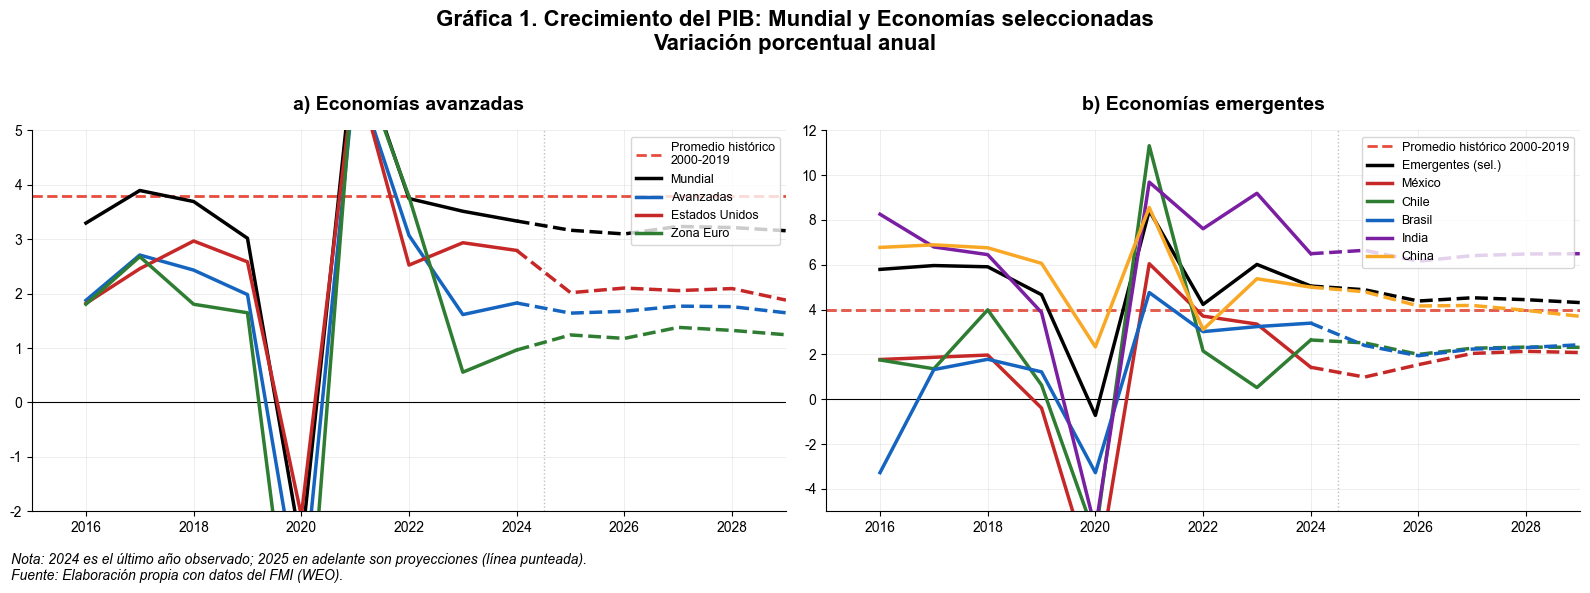


CUADRO. Crecimiento del PIB real (estimado con NGDP_R y ponderación PPPSH donde aplica)
Serie                         2023     2024     2025     2026
------------------------------------------------------------------------------------------
Mundial                        3.5      3.3      3.2      3.1
Avanzadas                      1.6      1.8      1.6      1.7
  Estados Unidos               2.9      2.8      2.0      2.1
  Zona Euro                    0.6      1.0      1.2      1.2
Emergentes (sel.)              6.0      5.1      4.9      4.4
  México                       3.4      1.4      1.0      1.5
  Chile                        0.5      2.6      2.5      2.0
  Brasil                       3.2      3.4      2.4      1.9
  India                        9.2      6.5      6.6      6.2
  China                        5.4      5.0      4.8      4.2


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D

# =============================
# 0) Estilo
# =============================
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# =============================
# 1) Cargar datos
# =============================
CSV_PATH = "raw/WEO.csv"  # <-- AJUSTA ESTO (ej: "/Users/emiliahernandez/Downloads/WEO.csv")
df = pd.read_csv(CSV_PATH)

# Años (ajusta si tu archivo tiene otros)
years = [str(y) for y in range(2015, 2030)]
years_plot = list(range(2015, 2030))

# Helper: limpiar numeric (WEO a veces trae cosas raras como 'n/a', '--', etc.)
def to_numeric_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace("…", "", regex=False)
         .str.replace("..", "", regex=False)
         .replace({"nan": np.nan, "None": np.nan, "N/A": np.nan, "n/a": np.nan, "--": np.nan, "": np.nan}),
        errors="coerce"
    )

# Partimos SERIES_CODE en piezas: ISO3.PREFIJO y variable
# Ejemplos: USA.NGDP_R.A, MEX.LP.A, USA.PPPSH.A
df["iso3"] = df["SERIES_CODE"].str.split(".").str[0]
df["var"]  = df["SERIES_CODE"].str.split(".").str[1]

# Nos quedamos con las 3 variables que usamos
df_small = df[df["var"].isin(["NGDP_R", "LP", "PPPSH"])].copy()

# Conservar solo las columnas relevantes
keep_cols = ["iso3", "COUNTRY", "var"] + years
df_small = df_small[keep_cols]

# Pasar a formato largo para trabajar bien
long = df_small.melt(
    id_vars=["iso3", "COUNTRY", "var"],
    value_vars=years,
    var_name="year",
    value_name="value"
)
long["value"] = to_numeric_series(long["value"])
long["year"] = long["year"].astype(int)

# Pivot: (iso3, COUNTRY, year) -> columnas NGDP_R, LP, PPPSH
wide = long.pivot_table(
    index=["iso3", "COUNTRY", "year"],
    columns="var",
    values="value",
    aggfunc="first"
).reset_index()

# =============================
# 2) Crecimientos por país
# =============================
# Crecimiento anual de NGDP_R y LP por iso3
wide = wide.sort_values(["iso3", "year"]).copy()
wide["gdp_growth"] = wide.groupby("iso3")["NGDP_R"].pct_change() * 100.0
wide["pop_growth"] = wide.groupby("iso3")["LP"].pct_change() * 100.0

# PPP share (PPPSH) lo dejamos como "peso" por año.
# Si PPPSH no existe para algún país/año, se ignora en el promedio ponderado.

def weighted_group_growth(df_wide: pd.DataFrame, iso_list: list[str], growth_col: str) -> pd.Series:
    """
    Regresa una serie indexada por year con el promedio ponderado por PPPSH.
    """
    sub = df_wide[df_wide["iso3"].isin(iso_list)].copy()
    # promedio ponderado por año: sum(w*x)/sum(w) usando PPPSH como pesos
    out = (
        sub.dropna(subset=[growth_col, "PPPSH"])
           .groupby("year")
           .apply(lambda g: np.average(g[growth_col], weights=g["PPPSH"]))
    )
    # asegurar todos los años en el índice
    return out.reindex(years_plot)

def single_country_growth(df_wide: pd.DataFrame, iso3: str, growth_col: str) -> pd.Series:
    sub = df_wide[df_wide["iso3"] == iso3].set_index("year")[growth_col]
    return sub.reindex(years_plot)

# =============================
# 3) Listas de países (ISO3)
# =============================
# Importante: estas listas son “de trabajo”. Puedes ajustarlas sin romper el código.

# Zona Euro (incluye miembros actuales; si no hay datos para alguno en tu CSV, no pasa nada)
EA_ISO = [
    "AUT","BEL","HRV","CYP","EST","FIN","FRA","DEU","GRC","IRL","ITA","LVA","LTU",
    "LUX","MLT","NLD","PRT","SVK","SVN","ESP"
]

# Avanzadas (aprox. IMF advanced; si quieres, luego afinamos)
ADV_ISO = [
    "USA","GBR","JPN","CAN","AUS","NZL","CHE","NOR","SWE","DNK","ISL","ISR","KOR",
    "SGP","TWN","HKG",
    # Europa avanzada (incluye EA + otros)
    "AUT","BEL","HRV","CYP","EST","FIN","FRA","DEU","GRC","IRL","ITA","LVA","LTU","LUX",
    "MLT","NLD","PRT","SVK","SVN","ESP",
    "CZE","HUN","POL","ROU","BGR","SVN","SVK",  # (algunas pueden ser EM en otras clasificaciones; si te molesta, las quitamos)
    "AND","SMR"
]

# Emergentes (para replicar tu panel: México, Chile, Brasil, India, China)
EM_SEL_ISO = ["MEX", "CHL", "BRA", "IND", "CHN"]

# Mundial: todos los países ISO3 de 3 letras (excluye agregados tipo G110, GX123, etc.)
WORLD_ISO = sorted([x for x in wide["iso3"].unique() if len(x) == 3 and x.isalpha()])

# =============================
# 4) Construir series (GDP growth)
# =============================
projection_start_year = 2025
split_year = 2024  # último observado (tu nota)
# índice donde empieza punteado (incluye 2025 en adelante)
proj_mask = np.array(years_plot) >= projection_start_year

# Series principales
g_world = weighted_group_growth(wide, WORLD_ISO, "gdp_growth")
g_adv   = weighted_group_growth(wide, ADV_ISO,   "gdp_growth")
g_ea    = weighted_group_growth(wide, EA_ISO,    "gdp_growth")
g_usa   = single_country_growth(wide, "USA", "gdp_growth")

g_mex   = single_country_growth(wide, "MEX", "gdp_growth")
g_chl   = single_country_growth(wide, "CHL", "gdp_growth")
g_bra   = single_country_growth(wide, "BRA", "gdp_growth")
g_ind   = single_country_growth(wide, "IND", "gdp_growth")
g_chn   = single_country_growth(wide, "CHN", "gdp_growth")

g_em_sel = weighted_group_growth(wide, EM_SEL_ISO, "gdp_growth")  # emergentes (seleccionadas)

# =============================
# 5) Plot helper (sólido vs punteado)
# =============================
def plot_solid_dotted(ax, x, y, color, label=None, lw=2.5, z=3,
                      last_observed_year=2024, projection_start_year=2025):
    x = np.array(x)
    y = np.array(y, dtype=float)

    # 1) Parte observada (incluye 2024)
    solid_mask = x <= last_observed_year
    ax.plot(x[solid_mask], y[solid_mask], color=color, lw=lw, label=label, zorder=z)

    # 2) Parte proyectada: arranca en 2024 para “pegar” visualmente
    dotted_mask = x >= last_observed_year
    # pero para no puntear antes, solo se puntea desde 2024 hacia delante
    ax.plot(x[dotted_mask], y[dotted_mask], color=color, lw=lw, ls="--", zorder=z)


# =============================
# 6) FIGURA: Crecimiento del PIB (2 paneles)
# =============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ----- Panel a) Avanzadas -----
ax1.axhline(0, color="black", lw=0.8)
ax1.axvline(projection_start_year - 0.5, color="gray", ls=":", alpha=0.5, lw=1)

# Si quieres el promedio histórico 2000-2019 "exacto" hay que calcularlo.
# Aquí lo dejo como placeholder (pon tu número o lo calculamos con años 2000-2019 si tu CSV los trae).
ax1.axhline(y=3.8, color="#E74C3C", ls="--", lw=2, zorder=1)

# Mundial (negro), Avanzadas (azul), USA (rojo), Zona Euro (verde)
plot_solid_dotted(ax1, years_plot, g_world.values, "#000000", label="Mundial", lw=2.5, z=3)
plot_solid_dotted(ax1, years_plot, g_adv.values,   "#1565C0", label="Avanzadas", lw=2.5, z=2)
plot_solid_dotted(ax1, years_plot, g_usa.values,   "#C62828", label="Estados Unidos", lw=2.5, z=3)
plot_solid_dotted(ax1, years_plot, g_ea.values,    "#2E7D32", label="Zona Euro", lw=2.5, z=3)

ax1.set_title("a) Economías avanzadas", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlim(2015, 2029)
ax1.set_ylim(-2, 5)
ax1.grid(True, alpha=0.3, lw=0.5)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

legend_elements_a = [
    Line2D([0],[0], color="#E74C3C", ls="--", lw=2, label="Promedio histórico\n2000-2019"),
    Line2D([0],[0], color="#000000", lw=2.5, label="Mundial"),
    Line2D([0],[0], color="#1565C0", lw=2.5, label="Avanzadas"),
    Line2D([0],[0], color="#C62828", lw=2.5, label="Estados Unidos"),
    Line2D([0],[0], color="#2E7D32", lw=2.5, label="Zona Euro"),
]
ax1.legend(handles=legend_elements_a, loc="upper right", fontsize=9, frameon=True)

# ----- Panel b) Emergentes (seleccionadas) -----
ax2.axhline(0, color="black", lw=0.8)
ax2.axvline(projection_start_year - 0.5, color="gray", ls=":", alpha=0.5, lw=1)
ax2.axhline(y=4.0, color="#E74C3C", ls="--", lw=2, zorder=1)

# Colores como tu referencia
plot_solid_dotted(ax2, years_plot, g_em_sel.values, "#000000", label="Emergentes (sel.)", lw=2.5, z=2)  # negro
plot_solid_dotted(ax2, years_plot, g_mex.values,    "#C62828", label="México", lw=2.5, z=3)            # rojo
plot_solid_dotted(ax2, years_plot, g_chl.values,    "#2E7D32", label="Chile", lw=2.5, z=3)             # verde
plot_solid_dotted(ax2, years_plot, g_bra.values,    "#1565C0", label="Brasil", lw=2.5, z=3)            # azul
plot_solid_dotted(ax2, years_plot, g_ind.values,    "#7B1FA2", label="India", lw=2.5, z=3)             # morado
plot_solid_dotted(ax2, years_plot, g_chn.values,    "#F9A825", label="China", lw=2.5, z=3)             # amarillo

ax2.set_title("b) Economías emergentes", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlim(2015, 2029)
ax2.set_ylim(-5, 12)
ax2.grid(True, alpha=0.3, lw=0.5)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

legend_elements_b = [
    Line2D([0],[0], color="#E74C3C", ls="--", lw=2, label="Promedio histórico 2000-2019"),
    Line2D([0],[0], color="#000000", lw=2.5, label="Emergentes (sel.)"),
    Line2D([0],[0], color="#C62828", lw=2.5, label="México"),
    Line2D([0],[0], color="#2E7D32", lw=2.5, label="Chile"),
    Line2D([0],[0], color="#1565C0", lw=2.5, label="Brasil"),
    Line2D([0],[0], color="#7B1FA2", lw=2.5, label="India"),
    Line2D([0],[0], color="#F9A825", lw=2.5, label="China"),
]
ax2.legend(handles=legend_elements_b, loc="upper right", fontsize=9, frameon=True)

fig.suptitle(
    "Gráfica 1. Crecimiento del PIB: Mundial y Economías seleccionadas\nVariación porcentual anual",
    fontsize=16, fontweight="bold", y=0.98
)

fig.text(
     0.01, 0.03,
    "Nota: 2024 es el último año observado; 2025 en adelante son proyecciones (línea punteada).\n"
    "Fuente: Elaboración propia con datos del FMI (WEO).",
     fontsize=10, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

# =============================
# 7) (Opcional) Tabla rápida 2023-2026
# =============================
def grab_values(series: pd.Series, years_):
    out = {}
    for y in years_:
        v = series.loc[y]
        out[y] = None if pd.isna(v) else float(v)
    return out

table_years = [2023, 2024, 2025, 2026]
rows = [
    ("Mundial", g_world),
    ("Avanzadas", g_adv),
    ("  Estados Unidos", g_usa),
    ("  Zona Euro", g_ea),
    ("Emergentes (sel.)", g_em_sel),
    ("  México", g_mex),
    ("  Chile", g_chl),
    ("  Brasil", g_bra),
    ("  India", g_ind),
    ("  China", g_chn),
]

print("\n" + "="*90)
print("CUADRO. Crecimiento del PIB real (estimado con NGDP_R y ponderación PPPSH donde aplica)")
print("="*90)
print(f"{'Serie':<25} " + " ".join([f"{y:>8}" for y in table_years]))
print("-"*90)
for name, ser in rows:
    vals = [ser.loc[y] if y in ser.index else np.nan for y in table_years]
    vals_fmt = [("n/d" if pd.isna(v) else f"{v:0.1f}") for v in vals]
    print(f"{name:<25} " + " ".join([f"{v:>8}" for v in vals_fmt]))
print("="*90)


In [ ]:
[c for c in df.columns if "ESTIMATE" in c.upper() or "FORECAST" in c.upper()]


[]

In [ ]:
df.head()


,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FREQUENCY,SCALE,1980,1981,1982,...,2023,2024,2025,2026,2027,2028,2029,2030,iso3,var
0,IMF.RES:WEO(9.0.0),HND.LP.A,OBS_VALUE,Honduras,"Population, Persons for countries / Index for ...",Annual,Millions,3.673,3.790,3.908,...,10.475,10.659,10.846,11.037,11.231,11.428,11.629,11.833,HND,LP
1,IMF.RES:WEO(9.0.0),BHS.LP.A,OBS_VALUE,"Bahamas, The","Population, Persons for countries / Index for ...",Annual,Millions,0.211,0.215,0.220,...,0.404,0.408,0.413,0.417,0.421,0.425,0.429,0.434,BHS,LP
2,IMF.RES:WEO(9.0.0),DMA.LP.A,OBS_VALUE,Dominica,"Population, Persons for countries / Index for ...",Annual,Millions,NaN,0.074,0.074,...,0.074,0.075,0.075,0.076,0.076,0.076,0.077,0.077,DMA,LP
3,IMF.RES:WEO(9.0.0),PRI.LP.A,OBS_VALUE,Puerto Rico,"Population, Persons for countries / Index for ...",Annual,Millions,3.203,3.229,3.257,...,3.206,3.177,3.175,3.174,3.172,3.171,3.169,3.168,PRI,LP
4,IMF.RES:WEO(9.0.0),QAT.LP.A,OBS_VALUE,Qatar,"Population, Persons for countries / Index for ...",Annual,Millions,0.245,0.265,0.285,...,3.063,3.094,3.109,3.125,3.140,3.156,3.172,3.188,QAT,LP


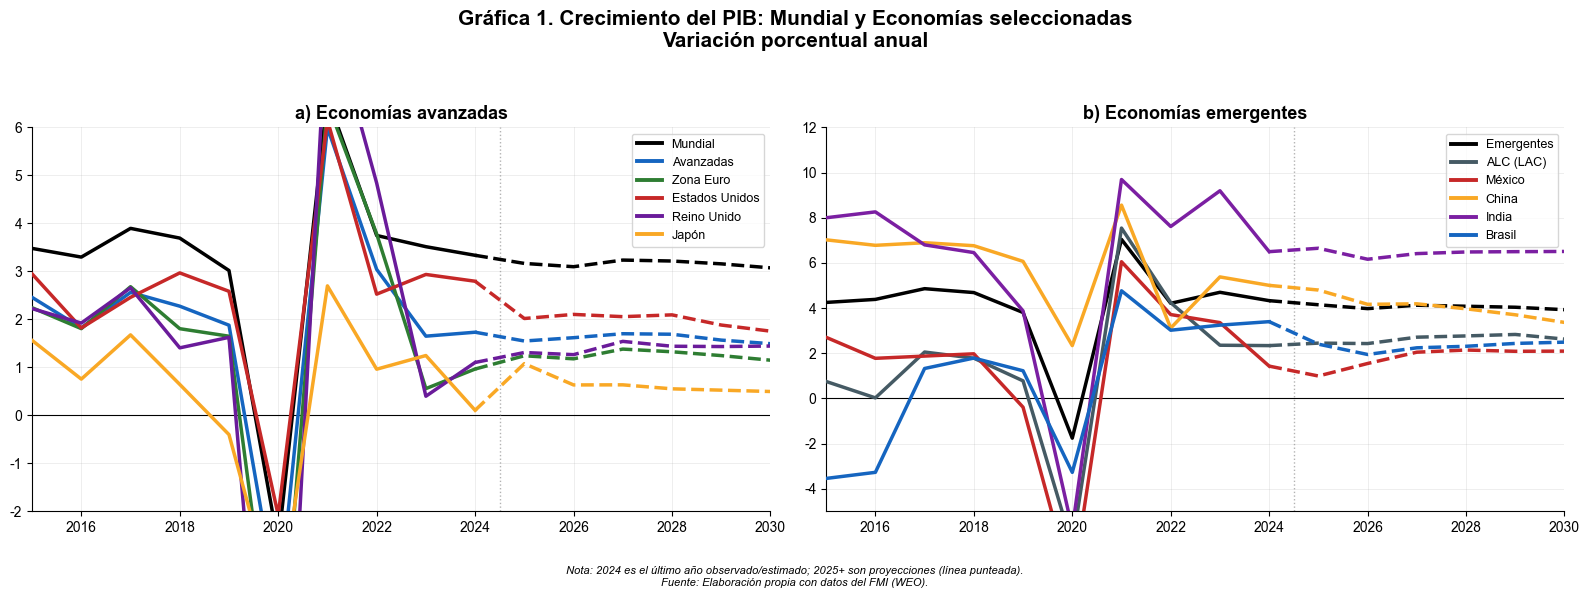

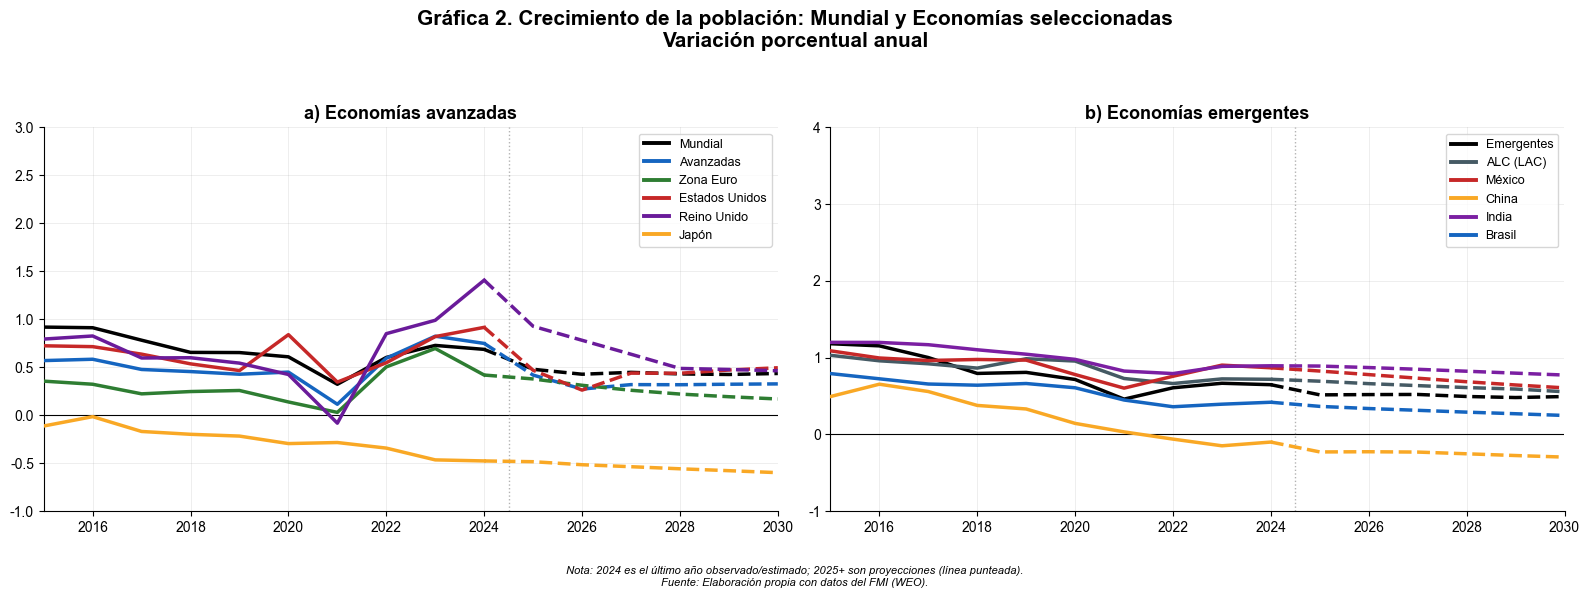


CUADRO 1A. Avanzados: crecimiento del PIB real
Variación anual en %
Serie                               2023       2024       2025       2026      
------------------------------------------------------------------------------------------------------------------------
Mundial                             3.5        3.3        3.2        3.1       
Avanzadas                           1.6        1.7        1.5        1.6       
Zona Euro                           0.6        1.0        1.2        1.2       
Estados Unidos                      2.9        2.8        2.0        2.1       
Reino Unido                         0.4        1.1        1.3        1.3       
Japón                               1.2        0.1        1.1        0.6       

CUADRO 1B. Emergentes: crecimiento del PIB real
Variación anual en %
Serie                               2023       2024       2025       2026      
----------------------------------------------------------------------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D
import re

# =============================
# 0) CONFIG
# =============================
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

CSV_PATH = "raw/WEO.csv"   # <-- cambia si aplica (ej. "WEO.csv")
SPLIT_YEAR = 2024          # último año observado/estimado
FORECAST_YEAR = 2025       # inicio proyección (dibujo punteado desde 2024 para pegar)

# Paneles (China solo en emergentes, sin Rusia)
ADV_PANEL = ["World", "Advanced Economies", "Euro Area (EA)", "United States", "United Kingdom", "Japan"]
EM_PANEL  = ["Emerging Market and Developing Economies", "Latin America and the Caribbean (LAC)",
             "Mexico", "China, People's Republic of", "India", "Brazil"]

# Etiquetas cortas
LABELS = {
    "World": "Mundial",
    "Advanced Economies": "Avanzadas",
    "Euro Area (EA)": "Zona Euro",
    "United States": "Estados Unidos",
    "United Kingdom": "Reino Unido",
    "Japan": "Japón",
    "Emerging Market and Developing Economies": "Emergentes",
    "Latin America and the Caribbean (LAC)": "ALC (LAC)",
    "Mexico": "México",
    "China, People's Republic of": "China",
    "India": "India",
    "Brazil": "Brasil",
}

# Colores (ajusta si quieres)
COL = {
    "World": "#000000",
    "Advanced Economies": "#1565C0",
    "Euro Area (EA)": "#2E7D32",
    "United States": "#C62828",
    "United Kingdom": "#6A1B9A",
    "Japan": "#F9A825",
    "Emerging Market and Developing Economies": "#000000",
    "Latin America and the Caribbean (LAC)": "#455A64",
    "Mexico": "#C62828",
    "China, People's Republic of": "#F9A825",
    "India": "#7B1FA2",
    "Brazil": "#1565C0",
}

# Indicadores (exactos del WEO.csv)
IND_GDP_REAL = "Gross domestic product (GDP), Constant prices, Domestic currency"
IND_POP      = "Population, Persons for countries / Index for country groups"
IND_PPPSH    = "Gross domestic product (GDP), Purchasing power parity (PPP) international dollar, percent of world GDP, Percent, ICP benchmarks 2017-2021"

# =============================
# 1) CARGA Y PREPARACIÓN
# =============================
df = pd.read_csv(CSV_PATH)

# columnas de años
year_cols = [c for c in df.columns if re.fullmatch(r"\d{4}", str(c))]
year_cols_int = sorted([int(c) for c in year_cols])

# iso3 desde SERIES_CODE (ISO3.VARIABLE.A)
df["iso3"] = df["SERIES_CODE"].astype(str).str.split(".").str[0]

def to_long(subdf, value_name):
    out = subdf[["iso3", "COUNTRY"] + year_cols].copy()
    out = out.melt(id_vars=["iso3", "COUNTRY"], var_name="year", value_name=value_name)
    out["year"] = out["year"].astype(int)
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    return out

# Subsets
gdp_long = to_long(df[df["INDICATOR"] == IND_GDP_REAL].copy(), "NGDP_R")
pop_long = to_long(df[df["INDICATOR"] == IND_POP].copy(), "LP")
ppp_long = to_long(df[df["INDICATOR"] == IND_PPPSH].copy(), "PPPSH")  # percent of world GDP (PPP)

# Panel país-año
panel = (
    gdp_long.merge(pop_long, on=["iso3", "COUNTRY", "year"], how="outer")
            .merge(ppp_long, on=["iso3", "COUNTRY", "year"], how="left")
).sort_values(["iso3", "year"])

# Crecimientos por país
panel["gdp_growth"] = panel.groupby("iso3")["NGDP_R"].pct_change() * 100
panel["pop_growth"] = panel.groupby("iso3")["LP"].pct_change() * 100

# Diccionario COUNTRY->iso3
name_to_iso3 = (df[["COUNTRY","iso3"]].drop_duplicates().set_index("COUNTRY")["iso3"]).to_dict()

# Universo de países con NGDP_R
iso3_universe = sorted(panel.loc[panel["NGDP_R"].notna(), "iso3"].unique().tolist())

# =============================
# 2) GRUPOS ISO3 PARA AGREGADOS (aproximación razonable)
# =============================
EURO_AREA = [
    "AUT","BEL","HRV","CYP","EST","FIN","FRA","DEU","GRC","IRL","ITA",
    "LVA","LTU","LUX","MLT","NLD","PRT","SVK","SVN","ESP"
]

LAC = [
    "ARG","BHS","BRB","BLZ","BOL","BRA","CHL","COL","CRI","CUB","DMA","DOM","ECU",
    "SLV","GRD","GTM","GUY","HTI","HND","JAM","MEX","NIC","PAN","PRY","PER","KNA",
    "LCA","VCT","SUR","TTO","URY","VEN","ATG"
]

ADVANCED = [
    "USA","CAN","GBR","JPN","DEU","FRA","ITA","ESP","NLD","BEL","AUT","FIN","IRL","PRT","GRC","LUX",
    "CHE","SWE","NOR","DNK","ISL","AUS","NZL","KOR","SGP","ISR","MLT","CYP","SVN","SVK","EST","LVA","LTU",
    "CZE"
]

EMDE = [x for x in iso3_universe if x not in set(ADVANCED)]

def weighted_group_growth(group_iso3, growth_col):
    """
    Promedio anual ponderado por PPPSH (PPP share, % del PIB mundial PPP).
    Si no hay pesos válidos en un año -> promedio simple.
    """
    tmp = panel.loc[panel["iso3"].isin(group_iso3), ["year", growth_col, "PPPSH"]].dropna(subset=["year", growth_col])
    if tmp.empty:
        return pd.Series(dtype=float)

    def agg_year(g):
        x = g[growth_col].to_numpy(dtype=float)
        w = g["PPPSH"].to_numpy(dtype=float)

        mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
        if mask.sum() >= 1:
            return float(np.average(x[mask], weights=w[mask]))

        # fallback sin pesos
        mask2 = np.isfinite(x)
        return float(np.nanmean(x[mask2])) if mask2.sum() else np.nan

    return tmp.groupby("year").apply(agg_year).sort_index()

def country_series(country_name, growth_col):
    iso3 = name_to_iso3.get(country_name)
    if iso3 is None:
        return pd.Series(dtype=float)
    s = panel.loc[panel["iso3"] == iso3, ["year", growth_col]].dropna()
    if s.empty:
        return pd.Series(dtype=float)
    return s.set_index("year")[growth_col].sort_index()

# Construcción de series PIB y POB
series_gdp = {}
series_pop = {}

# Agregados ponderados (World + grupos)
series_gdp["World"] = weighted_group_growth(iso3_universe, "gdp_growth")
series_pop["World"] = weighted_group_growth(iso3_universe, "pop_growth")

series_gdp["Advanced Economies"] = weighted_group_growth(ADVANCED, "gdp_growth")
series_pop["Advanced Economies"] = weighted_group_growth(ADVANCED, "pop_growth")

series_gdp["Emerging Market and Developing Economies"] = weighted_group_growth(EMDE, "gdp_growth")
series_pop["Emerging Market and Developing Economies"] = weighted_group_growth(EMDE, "pop_growth")

series_gdp["Euro Area (EA)"] = weighted_group_growth(EURO_AREA, "gdp_growth")
series_pop["Euro Area (EA)"] = weighted_group_growth(EURO_AREA, "pop_growth")

series_gdp["Latin America and the Caribbean (LAC)"] = weighted_group_growth(LAC, "gdp_growth")
series_pop["Latin America and the Caribbean (LAC)"] = weighted_group_growth(LAC, "pop_growth")

# Países (desde NGDP_R / LP)
for c in ["United States","United Kingdom","Japan","Mexico","Brazil","India","China, People's Republic of"]:
    series_gdp[c] = country_series(c, "gdp_growth")
    series_pop[c] = country_series(c, "pop_growth")

# =============================
# 3) PLOT HELPERS
# =============================
years_plot = list(range(2015, 2031))

def plot_solid_and_dotted(ax, s, key, lw=2.5, z=3):
    """
    Dibuja línea sólida hasta SPLIT_YEAR y punteada desde SPLIT_YEAR (incluye el punto 2024)
    para que NO haya corte visual.
    """
    s = s.reindex(years_plot)
    x = s.index.to_numpy()
    y = s.values

    solid_mask  = x <= SPLIT_YEAR
    dotted_mask = x >= SPLIT_YEAR

    ax.plot(x[solid_mask],  y[solid_mask],  color=COL.get(key,"gray"), lw=lw, zorder=z)
    ax.plot(x[dotted_mask], y[dotted_mask], color=COL.get(key,"gray"), lw=lw, ls="--", zorder=z)

def set_axis_style(ax, ylim):
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(SPLIT_YEAR + 0.5, color="gray", ls=":", alpha=0.6, lw=1)
    ax.grid(True, alpha=0.25, lw=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(2015, 2030)
    ax.set_ylim(*ylim)

def build_legend_handles(keys):
    """
    Leyenda 100% controlada: un handle por serie.
    """
    handles = []
    for k in keys:
        handles.append(Line2D([0],[0], color=COL.get(k,"gray"), lw=2.8, label=LABELS.get(k,k)))
    return handles

# =============================
# 4) FIGURA 1: PIB
# =============================
fig1, (axA, axB) = plt.subplots(1, 2, figsize=(16, 6))

set_axis_style(axA, ylim=(-2, 6))
axA.set_title("a) Economías avanzadas", fontsize=13, fontweight="bold")
for k in ADV_PANEL:
    plot_solid_and_dotted(axA, series_gdp.get(k, pd.Series(dtype=float)), k)

# Leyenda (manual, segura)
axA.legend(handles=build_legend_handles(ADV_PANEL), loc="upper right", fontsize=9, frameon=True)

set_axis_style(axB, ylim=(-5, 12))
axB.set_title("b) Economías emergentes", fontsize=13, fontweight="bold")
for k in EM_PANEL:
    plot_solid_and_dotted(axB, series_gdp.get(k, pd.Series(dtype=float)), k)

axB.legend(handles=build_legend_handles(EM_PANEL), loc="upper right", fontsize=9, frameon=True)

fig1.suptitle("Gráfica 1. Crecimiento del PIB: Mundial y Economías seleccionadas\nVariación porcentual anual",
              fontsize=15, fontweight="bold", y=0.98)

fig1.text(
    0.5, 0.02,
    f"Nota: {SPLIT_YEAR} es el último año observado/estimado; {FORECAST_YEAR}+ son proyecciones (línea punteada).\n"
    "Fuente: Elaboración propia con datos del FMI (WEO).",
    ha="center", fontsize=8, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])

# =============================
# 5) FIGURA 2: POBLACIÓN
# =============================
fig2, (axC, axD) = plt.subplots(1, 2, figsize=(16, 6))

set_axis_style(axC, ylim=(-1, 3))
axC.set_title("a) Economías avanzadas", fontsize=13, fontweight="bold")
for k in ADV_PANEL:
    plot_solid_and_dotted(axC, series_pop.get(k, pd.Series(dtype=float)), k)
axC.legend(handles=build_legend_handles(ADV_PANEL), loc="upper right", fontsize=9, frameon=True)

set_axis_style(axD, ylim=(-1, 4))
axD.set_title("b) Economías emergentes", fontsize=13, fontweight="bold")
for k in EM_PANEL:
    plot_solid_and_dotted(axD, series_pop.get(k, pd.Series(dtype=float)), k)
axD.legend(handles=build_legend_handles(EM_PANEL), loc="upper right", fontsize=9, frameon=True)

fig2.suptitle("Gráfica 2. Crecimiento de la población: Mundial y Economías seleccionadas\nVariación porcentual anual",
              fontsize=15, fontweight="bold", y=0.98)

fig2.text(
    0.5, 0.02,
    f"Nota: {SPLIT_YEAR} es el último año observado/estimado; {FORECAST_YEAR}+ son proyecciones (línea punteada).\n"
    "Fuente: Elaboración propia con datos del FMI (WEO).",
    ha="center", fontsize=8, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])

plt.show()

# =============================
# 6) TABLAS 2023–2026
# =============================
def print_table(title, series_dict, keys, years=(2023, 2024, 2025, 2026), fmt="{:.1f}"):
    print("\n" + "="*120)
    print(title)
    print("Variación anual en %")
    print("="*120)
    print(f"{'Serie':<35} " + " ".join([f"{y:<10}" for y in years]))
    print("-"*120)

    for k in keys:
        s = series_dict.get(k, pd.Series(dtype=float))
        vals = []
        for y in years:
            v = s.get(y, np.nan)
            vals.append(fmt.format(v) if np.isfinite(v) else "n/d")
        print(f"{LABELS.get(k,k):<35} " + " ".join([f"{v:<10}" for v in vals]))

    print("="*120)

print_table("CUADRO 1A. Avanzados: crecimiento del PIB real", series_gdp, ADV_PANEL, fmt="{:.1f}")
print_table("CUADRO 1B. Emergentes: crecimiento del PIB real", series_gdp, EM_PANEL, fmt="{:.1f}")

print_table("CUADRO 2A. Avanzados: crecimiento de la población", series_pop, ADV_PANEL, fmt="{:.2f}")
print_table("CUADRO 2B. Emergentes: crecimiento de la población", series_pop, EM_PANEL, fmt="{:.2f}")


### La buena, correcion de colores calculos, etc

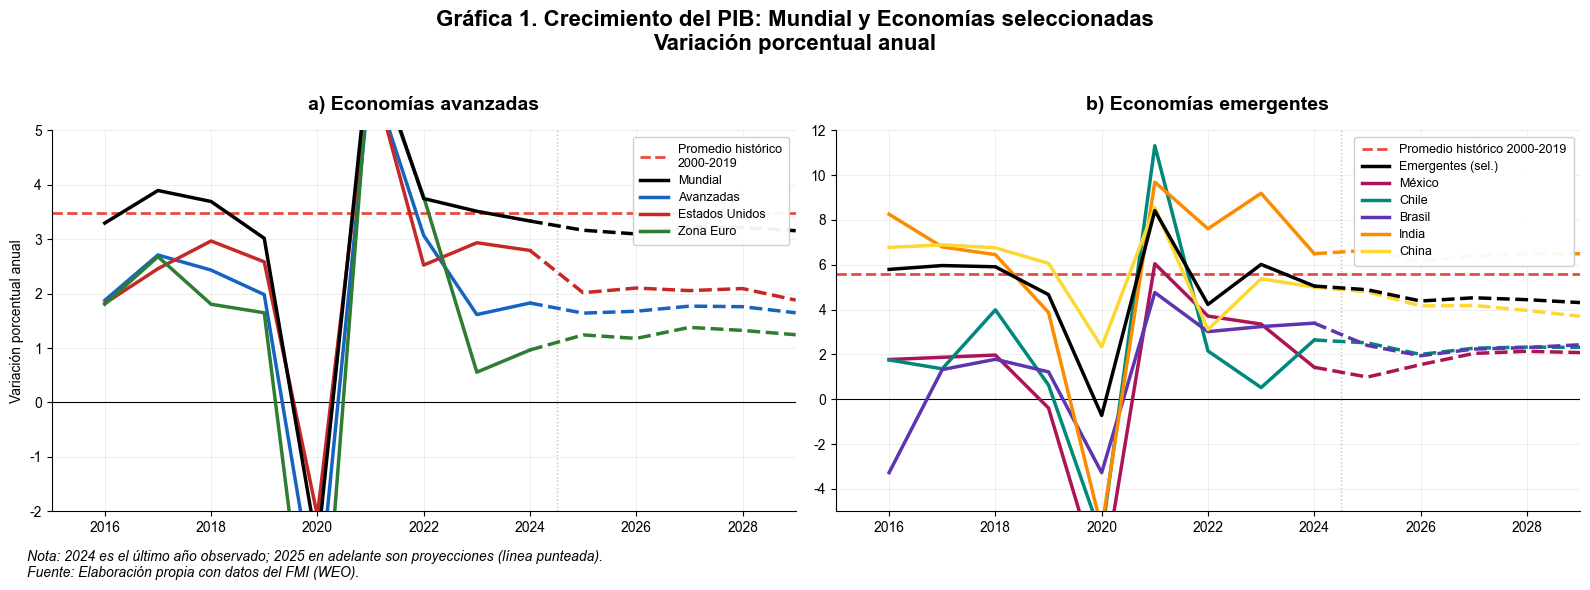

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Helpers de estilo (mismo formato que tus otras gráficas)
# ============================================================
def style_axes(ax):
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def legend_box(ax, handles, loc="upper right"):
    ax.legend(
        handles=handles,
        loc=loc,
        fontsize=9,
        frameon=True,
        framealpha=0.95,
        borderpad=0.6,
        labelspacing=0.4,
        handlelength=2.2,
    )

def hist_mean(series: "pd.Series", start=2000, end=2019):
    s = series.dropna()
    s = s[(s.index >= start) & (s.index <= end)]
    if s.empty:
        return np.nan
    return float(s.mean())

# ============================================================
# COLORES: distintos entre paneles
# ============================================================
# Panel a (avanzadas): paleta "A"
COL_A = {
    "World": "#000000",
    "Adv":   "#1565C0",  # azul
    "USA":   "#C62828",  # rojo
    "EA":    "#2E7D32",  # verde
}

# Panel b (emergentes): paleta "B" (distinta a panel a)
COL_E = {
    "EmSel": "#000000",  # negro (línea resumen)
    "MEX":   "#AD1457",  # magenta oscuro (distinto al rojo USA)
    "CHL":   "#00897B",  # teal (distinto al verde EA)
    "BRA":   "#5E35B1",  # púrpura (distinto al azul Adv)
    "IND":   "#FB8C00",  # naranja
    "CHN":   "#FDD835",  # amarillo
}

COL_HIST = "#E74C3C"     # rojo punteado para promedio histórico (igual en ambos paneles)

# ============================================================
# Promedios históricos 2000–2019 (calculados)
# ============================================================
hist_world = hist_mean(g_world, 2000, 2019)
hist_emsel = hist_mean(g_em_sel, 2000, 2019)

# ============================================================
# FIGURA
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------- Panel a) Avanzadas
style_axes(ax1)
ax1.axhline(0, color="black", lw=0.8)
ax1.axvline(projection_start_year - 0.5, color="gray", ls=":", alpha=0.5, lw=1)

# Promedio histórico (si existe)
if not np.isnan(hist_world):
    ax1.axhline(y=hist_world, color=COL_HIST, ls="--", lw=2, zorder=1)

# Series (sólido observado / punteado proyección)
plot_solid_dotted(ax1, years_plot, g_world.values, COL_A["World"], label="Mundial", lw=2.5, z=4)
plot_solid_dotted(ax1, years_plot, g_adv.values,   COL_A["Adv"],   label="Avanzadas", lw=2.5, z=3)
plot_solid_dotted(ax1, years_plot, g_usa.values,   COL_A["USA"],   label="Estados Unidos", lw=2.5, z=3)
plot_solid_dotted(ax1, years_plot, g_ea.values,    COL_A["EA"],    label="Zona Euro", lw=2.5, z=3)

ax1.set_title("a) Economías avanzadas", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlim(2015, 2029)
ax1.set_ylim(-2, 5)
ax1.set_ylabel("Variación porcentual anual")

legend_elements_a = []
if not np.isnan(hist_world):
    legend_elements_a.append(Line2D([0],[0], color=COL_HIST, ls="--", lw=2, label="Promedio histórico\n2000-2019"))
legend_elements_a += [
    Line2D([0],[0], color=COL_A["World"], lw=2.5, label="Mundial"),
    Line2D([0],[0], color=COL_A["Adv"],   lw=2.5, label="Avanzadas"),
    Line2D([0],[0], color=COL_A["USA"],   lw=2.5, label="Estados Unidos"),
    Line2D([0],[0], color=COL_A["EA"],    lw=2.5, label="Zona Euro"),
]
legend_box(ax1, legend_elements_a, loc="upper right")

# ---------------- Panel b) Emergentes
style_axes(ax2)
ax2.axhline(0, color="black", lw=0.8)
ax2.axvline(projection_start_year - 0.5, color="gray", ls=":", alpha=0.5, lw=1)

if not np.isnan(hist_emsel):
    ax2.axhline(y=hist_emsel, color=COL_HIST, ls="--", lw=2, zorder=1)

plot_solid_dotted(ax2, years_plot, g_em_sel.values, COL_E["EmSel"], label="Emergentes (sel.)", lw=2.5, z=4)
plot_solid_dotted(ax2, years_plot, g_mex.values,    COL_E["MEX"],   label="México", lw=2.5, z=3)
plot_solid_dotted(ax2, years_plot, g_chl.values,    COL_E["CHL"],   label="Chile", lw=2.5, z=3)
plot_solid_dotted(ax2, years_plot, g_bra.values,    COL_E["BRA"],   label="Brasil", lw=2.5, z=3)
plot_solid_dotted(ax2, years_plot, g_ind.values,    COL_E["IND"],   label="India", lw=2.5, z=3)
plot_solid_dotted(ax2, years_plot, g_chn.values,    COL_E["CHN"],   label="China", lw=2.5, z=3)

ax2.set_title("b) Economías emergentes", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlim(2015, 2029)
ax2.set_ylim(-5, 12)

legend_elements_b = []
if not np.isnan(hist_emsel):
    legend_elements_b.append(Line2D([0],[0], color=COL_HIST, ls="--", lw=2, label="Promedio histórico 2000-2019"))
legend_elements_b += [
    Line2D([0],[0], color=COL_E["EmSel"], lw=2.5, label="Emergentes (sel.)"),
    Line2D([0],[0], color=COL_E["MEX"],   lw=2.5, label="México"),
    Line2D([0],[0], color=COL_E["CHL"],   lw=2.5, label="Chile"),
    Line2D([0],[0], color=COL_E["BRA"],   lw=2.5, label="Brasil"),
    Line2D([0],[0], color=COL_E["IND"],   lw=2.5, label="India"),
    Line2D([0],[0], color=COL_E["CHN"],   lw=2.5, label="China"),
]
legend_box(ax2, legend_elements_b, loc="upper right")

# ---------------- Título + nota (mismo formato)
fig.suptitle(
    "Gráfica 1. Crecimiento del PIB: Mundial y Economías seleccionadas\nVariación porcentual anual",
    fontsize=16, fontweight="bold", y=0.98
)

fig.text(
    0.02, 0.03,
    "Nota: 2024 es el último año observado; 2025 en adelante son proyecciones (línea punteada).\n"
    "Fuente: Elaboración propia con datos del FMI (WEO).",
     va="bottom", fontsize=10, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()
